In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import geopandas as gpd
import functions.plotting as fplt
from importlib import reload
reload(fplt)

<module 'functions.plotting' from 'c:\\FATE\\Code\\functions\\plotting.py'>

In [2]:
ds = gpd.read_parquet("Data/Mapped_SAT_MI_Cleanedspeeds.parquet")
i = 1991
Ux= ds.at[i,"x_speed"]
Uy = ds.at[i,"y_speed"]
t = ds.at[i,"TimeStamp"]
print(f"Startdate , enddate = { min(t), max(t)}")
print(f"Length of speeds and time (u,v,t):{ len(Ux), len(Uy), len(t)}")
print(Ux)

Startdate , enddate = ('2024-08-12 07:02:00', '2024-08-20 10:06:00')
Length of speeds and time (u,v,t):(50, 50, 50)
[-0.1648416  -0.08077747 -0.01976799 -0.04972503 -0.021438    0.05644687
 -0.01391859  0.05760515  0.13389722  0.15441177  0.13743631  0.13567325
  0.27460379  0.29590205  0.27659738  0.37933926  0.44657066  0.40037895
  0.41837091  0.42793898  0.44918117  0.45497257  0.45834952  0.46269444
  0.44130487  0.37003963  0.43739812  0.48353644  0.41371054  0.38949112
  0.35603908  0.37219413  0.30987864  0.22161767  0.26658867  0.23930075
  0.18040339  0.21523831  0.22802682  0.20253916  0.19003522  0.182766
  0.17917301  0.16110192  0.09436836  0.13744928  0.1237567   0.07119564
  0.05830012  0.00715154]


In [3]:
class Autocorrilation:
    def __init__(self, u,v,t ): 
        self.u = u #ds.at[i, "x_speed"]
        self.v = v #ds.at[i, "y_speed"]
        self.U = self.u+1j*self.v
        self.t = t # ds.at[i, "TimeStamp"]
        self.t = np.array(self.t, dtype='datetime64')
        self.Umean = np.mean(self.U)
        self.sigma2 = np.mean((np.abs(self.U - self.Umean))**2) 
        self.split = False
        return None
    def Normalize_t(self, dt:int):
        self.dt = np.timedelta64(dt, 'h')
        self.ti = np.arange(self.t[0], self.t[-1], self.dt, dtype='datetime64')
        ti_abs = self.ti.astype("float64")/8.64e4
        t_abs = self.t.astype("float64")/8.64e4
        self.ui = np.interp(ti_abs,t_abs, self.u)
        self.vi = np.interp(ti_abs,t_abs, self.v)
        self.Ui = self.ui +1j*self.vi
        self.Uimean = np.mean(self.Ui)
        #self.sigma2i = np.mean((np.abs(self.Ui - self.Uimean))**2)
        #self.sigma2i = np.mean((np.abs(self.Ui) - np.abs(self.Uimean))**2) ## Varience of magnitude of velocity (speeds)
        self.sigma2i = np.mean((self.Ui.real - self.Uimean.real)**2) + np.mean((self.Ui.imag - self.Uimean.imag)**2)
        return None
    def calc_autocorrelation(self, tau):
        tau = np.timedelta64(tau, 'h')
        t = self.ti ## check 1e9
        ## could also add a flag to see to interp data if not, then interp. 
        dt = t[1]-t[0]
        len_ts = int(len(t) - tau/dt) 
        taui= int(tau/dt)
        temp = 0
        for i in range(len_ts):
            a = self.Ui[i] - self.Uimean 
            b = self.Ui[i+taui] - self.Uimean
            temp +=  np.dot([a.real, a.imag], [b.real,b.imag])
            #np.real(np.vdot(self.Ui[i] -self.Uimean, self.Ui[i+taui] - self.Uimean)) #np.real((self.Ui[i] - self.Uimean) * np.conj(self.Ui[i + taui] - self.Uimean))
        self.temp = temp
        return temp/len_ts/self.sigma2i
    def calc_autocor_allTau(self):
        """Need to call Calc_autocorrelation for all Tau, First need to calc max range of Tau, then store Tau"""
        dtint = int(self.dt/np.timedelta64(1, "h"))
        self.Tau = []
        self.R = []
        for i in range(len(self.ti)-1):
            r = self.calc_autocorrelation(i*dtint)
            self.R.append(r)
            self.Tau.append(i*self.dt)
        return None        

In [4]:
class split_trajectory:
    def __init__(self, ds, i): 
        self.u = ds.at[i, "x_speed"]
        self.v = ds.at[i, "y_speed"]
        self.U = self.u+1j*self.v
        self.t = ds.at[i, "TimeStamp"]
        self.t = np.array(self.t, dtype='datetime64')
        self.split = False
        return None
    def splice_out_of_bounds(self):
        self.deltat = np.diff(self.t)/3600 ##converts to hours change. 
        split_idx = np.where(self.deltat > 26)[0]
        self.t = np.split(self.t, split_idx+1)
        self.u = np.split(self.u, split_idx+1)
        self.v = np.split(self.v, split_idx+1)
        self.U = np.split(self.U, split_idx+1)
        self.Umean = []
        self.sigma2 = []
        for i in range(len(self.U)):
            self.Umean.append(np.mean(self.U[i]))
            self.sigma2.append(np.mean((np.abs(self.U[i] - self.Umean[i]))**2))
        self.split = True
        return None
    

In [5]:
Tau_list = []
R_list = []
for dFAD in range(len(ds)):
    trajectories = split_trajectory(ds, dFAD)
    trajectories.splice_out_of_bounds()
    for i in range(len(trajectories.U)): ## amount of split trajecotries
        ac = Autocorrilation(trajectories.u[i],trajectories.v[i],trajectories.t[i])
        ac.Normalize_t(4)
        ac.calc_autocor_allTau()
        Tau_list.extend(ac.Tau)
        R_list.extend(ac.R)


c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
data = pd.DataFrame({"Tau": Tau_list, "R": R_list})
groupeddata  = data.groupby("Tau").mean()

In [7]:
## Lagrangian Integral time
from scipy.optimize import curve_fit
grouped7d = groupeddata[groupeddata.index < np.timedelta64(7, "D")]
print(f"numerical intergral of eq 4.4 {grouped7d.R.sum()*np.timedelta64(4,"h")}")

def func(x, a,b,c):
    return a*np.exp(-x/b)+c

ppot, cpot = curve_fit(func, grouped7d.index/np.timedelta64(1, "D"), grouped7d.R)
ppot

numerical intergral of eq 4.4 -14 hours


array([ 1.25303262,  0.85636577, -0.25485327])

Text(0, 0.3, ' a = 1.253 \n b = 0.856\n c = -0.255')

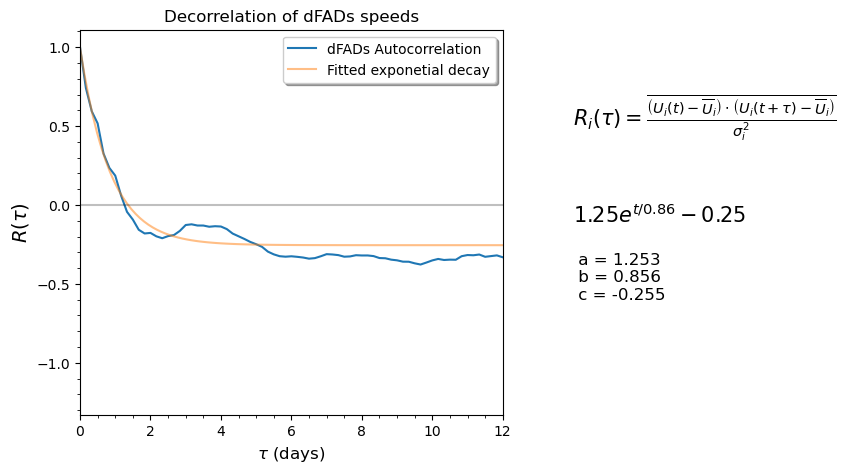

In [8]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3,2])
ax0 = fig.add_subplot(gs[0,0])
ax0.plot(groupeddata.index/np.timedelta64(24, 'h'), groupeddata.R, label = "dFADs Autocorrelation")
x = np.linspace(0,12, 100)
ax0.plot(x, func(x, ppot[0], ppot[1], ppot[2]),alpha = 0.5, label = "Fitted exponetial decay")
ax0.set_xlim(0,12)
ax0.set_ylabel(r"$R(\tau)$", fontsize = 14)
ax0.set_xlabel(r"$\tau$ (days)", fontsize = 12)
ax0.hlines(0,0, 300, color = "k", alpha = 0.25)
ax0.minorticks_on()
ax0.set_title("Decorrelation of dFADs speeds")
ax0.legend(fancybox = True, shadow = True)


ax1 = fig.add_subplot(gs[0,1])
ax1.axis("off")
ax1.text(0,0.75, r"$R_i(\tau) = \frac{\overline{\left(U_i(t) - \overline{U}_i\right)\cdot\left(U_i(t+\tau) - \overline{U}_i\right)}}{\sigma_i^2}$",
          fontdict={"fontsize" : 15})
#ax1.text(0, 0.5, r"$a e^{-\tau/b} + c$", fontsize = 15)
ax1.text(
    0, 0.5,
    rf"${ppot[0]:.2f} e^{{t/{ppot[1]:.2f}}} {ppot[2]:.2f}$", fontsize=15)
ax1.text(0, 0.3 ,f" a = {ppot[0] :.3f} \n b = {ppot[1]:.3f}\n c = {ppot[2] :.3f}", fontsize = 12)
#fig.savefig(r"..\Figures\Autocorrilation_ensanble.png")

### Plotting indvigual Trajectories along with their autocorrilation function. 

c:\FATE\Code\functions\plotting.py:122: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"],
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_8028\3761223299.py:19: UserWarning: Legend does not support handles for QuadContourSet instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend()


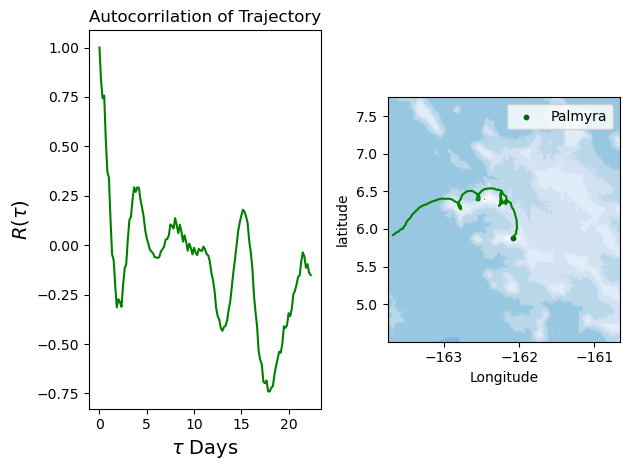

In [9]:
i = 1227
#1222 1224 # 1227

trajectories = split_trajectory(ds, i)
trajectories.splice_out_of_bounds()
traj = Autocorrilation(trajectories.u[0],trajectories.v[0], trajectories.t[0])
traj.Normalize_t(4)
traj.calc_autocor_allTau()
Tau_list.extend(ac.Tau)
R_list.extend(ac.R)


fig, ax = plt.subplots(1,2)

ax[0].plot(traj.Tau/np.timedelta64(1, "D"), traj.R, color = "g")
fplt.OneTrajectory(ds, i, ax[1], color = "g")
fplt.Add_bathymetry(fig, ax[1], colorbar = False)
fplt.Palmyra_plot(ax[1])
ax[1].legend()

ax[0].set_ylabel(r"$R(\tau)$", fontsize = 14)
ax[0].set_xlabel(r"$\tau$ Days", fontsize = 14)
ax[0].set_title("Autocorrilation of Trajectory")
ax[1].set_aspect("equal")
ax[1].set_label('Trajectory')
#ax[0].set_xlim(0,30)
fig.tight_layout()
fig.savefig(fr"../Figures/Autocorrilation_{i}")

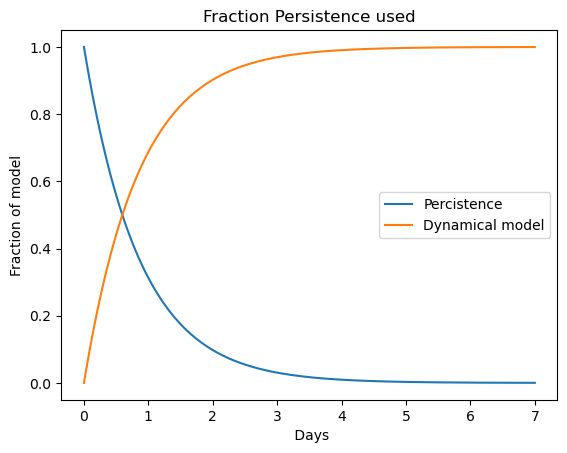

In [24]:
### Showing the percent of each model as leadtime 

t= np.linspace(0,7, 7*24-1)
pers = np.exp(-t/(0.86))
dynamical = 1 - np.exp(-t/(0.86))
fig, ax = plt.subplots()
ax.plot(t, pers, label = "Percistence")
ax.plot(t, dynamical, label = "Dynamical model")
ax.set(xlabel = " Days", ylabel = "Fraction of model", title = "Fraction Persistence used")
ax.legend()